# AGRI-2050 | Veri Keşfi & Analiz
**Bölge:** Konya Ovası | **Ürün:** Buğday | **Dönem:** 2010-2030

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Veri yolları
RAW_DIR  = '../data/raw/'
PROC_DIR = '../data/processed/'

## 1. Ham Veriyi Yükle

In [5]:
ndvi_df   = pd.read_csv(RAW_DIR + 'satellite_ndvi.csv', parse_dates=['date'])
precip_df = pd.read_csv(RAW_DIR + 'precipitation.csv')
yield_df  = pd.read_csv(RAW_DIR + 'crop_yields.csv')

print('NDVI shape   :', ndvi_df.shape)
print('Yağış shape  :', precip_df.shape)
print('Rekolte shape:', yield_df.shape)
ndvi_df.head()

NDVI shape   : (180, 8)
Yağış shape  : (180, 5)
Rekolte shape: (100, 10)


,date,year,month,ndvi,ndwi,lst_celsius,cloud_cover_pct,source
0,2010-01-15,2010,1,0.3898,0.0462,2.44,24.1,Sentinel-2/Landsat8 (simulated)
1,2010-02-15,2010,2,0.5084,0.1377,-0.09,9.7,Sentinel-2/Landsat8 (simulated)
2,2010-03-15,2010,3,0.6187,0.2373,-0.26,5.7,Sentinel-2/Landsat8 (simulated)
3,2010-04-15,2010,4,0.7676,0.2131,17.43,34.1,Sentinel-2/Landsat8 (simulated)
4,2010-05-15,2010,5,0.8481,0.2394,34.69,19.7,Sentinel-2/Landsat8 (simulated)


## 2. NDVI Zaman Serisi

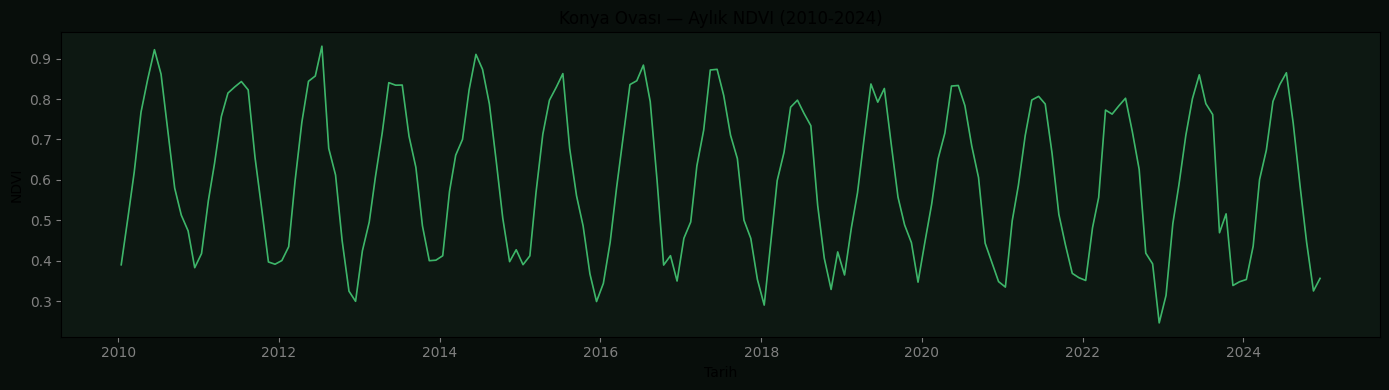

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ndvi_df['date'], ndvi_df['ndvi'], color='#4ade80', linewidth=1.2, alpha=0.8)
ax.set(title='Konya Ovası — Aylık NDVI (2010-2024)',
       xlabel='Tarih', ylabel='NDVI')
ax.set_facecolor('#0d1812')
fig.patch.set_facecolor('#080e0b')
ax.tick_params(colors='gray')
plt.tight_layout()
plt.savefig('../reports/ndvi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rekolte Trendi

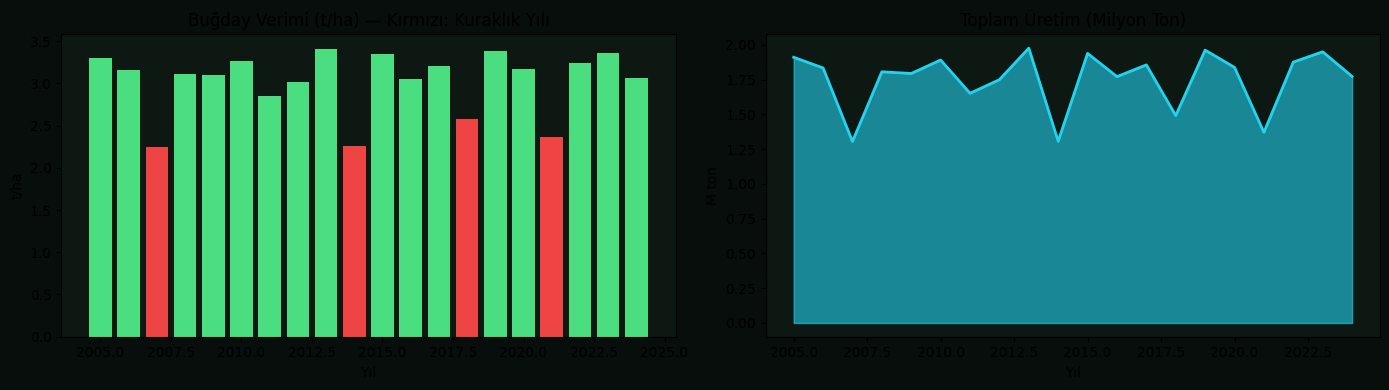

In [7]:
bugday = yield_df[yield_df['crop'] == 'bugday'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Yıllık verim
axes[0].bar(bugday['year'], bugday['yield_t_ha'],
            color=['#ef4444' if r else '#4ade80' for r in bugday['drought_year']])
axes[0].set(title='Buğday Verimi (t/ha) — Kırmızı: Kuraklık Yılı',
            xlabel='Yıl', ylabel='t/ha')

# Toplam üretim
axes[1].fill_between(bugday['year'], bugday['total_prod_t']/1e6,
                     alpha=0.6, color='#22d3ee')
axes[1].plot(bugday['year'], bugday['total_prod_t']/1e6, color='#22d3ee', linewidth=2)
axes[1].set(title='Toplam Üretim (Milyon Ton)', xlabel='Yıl', ylabel='M ton')

for ax in axes:
    ax.set_facecolor('#0d1812')
fig.patch.set_facecolor('#080e0b')
plt.tight_layout()
plt.savefig('../reports/yield_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. İşlenmiş Veri — Tahmin Sonuçları

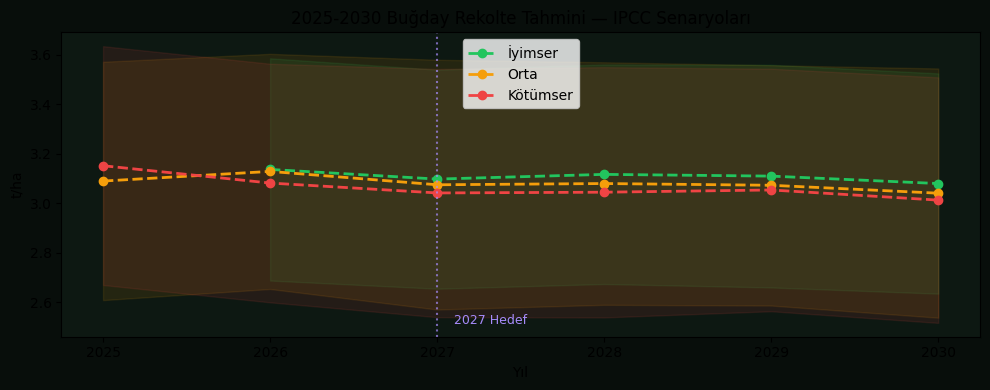


2027 Tahminleri:
     scenario_label  yield_t_ha  total_prod_t
 İyimser (SSP1-2.6)       3.098       1796752
    Orta (SSP2-4.5)       3.075       1783777
Kötümser (SSP5-8.5)       3.042       1764125


In [8]:
forecast = pd.read_csv(PROC_DIR + 'forecast_2025_2030.csv')

colors = {'optimist_ssp126':'#22c55e', 'orta_ssp245':'#f59e0b', 'kotumser_ssp585':'#ef4444'}
labels = {'optimist_ssp126':'İyimser', 'orta_ssp245':'Orta', 'kotumser_ssp585':'Kötümser'}

fig, ax = plt.subplots(figsize=(10, 4))
for sc, color in colors.items():
    sub = forecast[forecast['scenario'] == sc]
    ax.plot(sub['year'], sub['yield_t_ha'], 'o--',
            color=color, label=labels[sc], linewidth=2)
    ax.fill_between(sub['year'], sub['yield_lower_80'], sub['yield_upper_80'],
                    alpha=0.1, color=color)

ax.axvline(2027, color='#a78bfa', linestyle=':', alpha=0.7)
ax.text(2027.1, ax.get_ylim()[0]+0.05, '2027 Hedef', color='#a78bfa', fontsize=9)
ax.legend()
ax.set(title='2025-2030 Buğday Rekolte Tahmini — IPCC Senaryoları',
       xlabel='Yıl', ylabel='t/ha')
ax.set_facecolor('#0d1812')
fig.patch.set_facecolor('#080e0b')
plt.tight_layout()
plt.savefig('../reports/forecast_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n2027 Tahminleri:')
print(forecast[forecast['year']==2027][['scenario_label','yield_t_ha','total_prod_t']].to_string(index=False))